# Model Training Workflow

0. Manually train and tune a model
1. Once a good setup is found, train the model on the full data set, save the artifacts and and update the respective paths in config/model_config.py


Model improvement ideas:

1. Engineer rolling sales features (e.g. rolling mean sales with 6months window to be dynamic not static)
2. Perform hyperparameter tuning
3. EDA on features that effect size distribution
4. Add size_range as a feature and derive more features from it (e.g. avg sales per size in size range,...)

In [1]:
!pip install awswrangler
!pip install pyarrow==2 awswrangler
!pip install --upgrade google-api-python-client oauth2client

!pip install gspread
!pip install hvac
!pip install psycopg2
!pip install catboost

In [1]:
import sys 
import os
sys.path.append("/home/ec2-user/SageMaker/ml-demand-forecasting")

from catboost import CatBoostRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import DataConversionWarning
from pandas.core.common import SettingWithCopyWarning
import warnings
import matplotlib.pyplot as plt
import pickle
import awswrangler as wr
import seaborn as sns

from src.io.loaders import load_label_encoder
from src.io.loaders import upload_file_to_s3
from src.io.loaders import save_model_to_s3
from src.io.loaders import download_file_from_s3

from config.project_config import S3_BUCKET
#from config.model_config import LOCAL_ONLINE_MODEL_SAVE_PATH


from src.model.metrics import accuracy, bias
from sklearn.metrics import mean_squared_error, mean_absolute_error

from src.feature.feature_lib import add_price_features

from src.feature.feature_lib import (
    get_feature_distribution,
    add_mega_campaign,
    get_historic_week_dist_feature,
    get_size_distribution,
    get_historic_sales_statistics,
    add_price_features
)


warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings(action="ignore", category=DataConversionWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 10000)
pd.set_option("max_colwidth", 10000)


RUN_DATE = '18072022'
S3_FOLDER_PATH = f'data_science/dfm/online_clothing_v2/{RUN_DATE}'

MASTER_JOIN_FILE_PATH = f's3://{S3_BUCKET}/{S3_FOLDER_PATH}/master_join_online.parquet'
LABLE_ENCODER_FILE_PATH = f'{S3_FOLDER_PATH}/lable_encoder_online.pkl'
LOCAL_ONLINE_MODEL_SAVE_PATH = f'../../temp/model_saves/online/{RUN_DATE}/'

if not os.path.exists(f'{LOCAL_ONLINE_MODEL_SAVE_PATH}'):
    os.makedirs(f'{LOCAL_ONLINE_MODEL_SAVE_PATH}')

# Columns used for analysis but not for training
NO_TRAIN_COLS = ['date_released', 'release_collection_name', 'id_product', 'id_product_attribute']


def mean_abs_error_percent(y_true, y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    mean_demand = np.mean(y_true)
    return (mae / mean_demand) * 100

def report_model_performance(model_name: str, y_true, y_pred):
    acc = np.round(mean_abs_error_percent(y_true, y_pred))
    b = np.round(bias(y_true, y_pred),2)
    mae = np.round(mean_absolute_error(y_true, y_pred),2)
    avg_sales = np.round(np.mean(y_true),2)
    avg_pred = np.round(np.mean(y_pred),2)
    
    print(f'Percentage error of {model_name}: {acc}%')
    print(f'Bias of {model_name}: {b}')
    print(f'Mean absolute error of {model_name}: {mae}')
    print(f'Average actual sales: {avg_sales}')
    print(f'Average prediction: {avg_pred}')
    

/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/psycopg2/__init__.py:144: UserWarning: The psycopg2 wheel package will be renamed from release 2.8; in order to keep installing from binary please use "pip install psycopg2-binary" instead. For details see: <http://initd.org/psycopg/docs/install.html#binary-install-from-pypi>.
  """)


# Model Development

In [69]:
READ_COLS = [
    'tie', 'original_price_usd', 'first_week_of_month', 'product_cost_usd', 'is_lookbook_collection', 'year', 'giveaway',
    'warehouse', 'last_week_of_month', 'is_mega_campaign_order', 'discount_utilization', 'item_discount_percent', 'voucher_discount_percent',
    'adjusted_net_units_sold', 'styles_in_drop', 'is_big_collection', 'released_month', 'day_of_week',
    'week_id', 'sub_product_line', 'henry_category_1', 'henry_category_2', 'henry_category_3', 'simple_color',
    'color', 'fabric_custom_name', 'hscode_id_fabric_name', 'size', 'style', 'sleeve', 'pattern', 'sleevestyle',
    'neckline', 'shape', 'rise', 'size_dist', 'dist_lookbook',
] + NO_TRAIN_COLS

master_join = pd.read_parquet( MASTER_JOIN_FILE_PATH, columns = READ_COLS )
master_join = master_join[master_join.week_id <= 9]
master_join.sort_values(by = ['date_released','week_id'], inplace = True)


#test_set_collections = master_join.release_collection_name.unique()[-80:]
#print(test_set_collections)


In [70]:
''' Creating test set '''
NUM_TEST_SET_COLLECTIONS = int(master_join.release_collection_name.nunique() * 0.15)

temp = master_join.groupby('release_collection_name')['date_released'].min().reset_index()
temp.sort_values(by = 'date_released', inplace = True)
test_set_collections = temp['release_collection_name'][-NUM_TEST_SET_COLLECTIONS:]

data_test = master_join[master_join.release_collection_name.isin(test_set_collections)]

data_train = master_join[~master_join.release_collection_name.isin(test_set_collections)]
data_train = data_train[data_train.year > 2019]
data_train = data_train[data_train.adjusted_net_units_sold <= data_train.adjusted_net_units_sold.quantile(0.97)]

# Clean remaining dates in 2022
max_train_set_date = data_train.date_released.max()
min_test_set_date = data_test.date_released.min()


# Clean overlapping date in data train. This comes from having multiple release dates in different countries
data_train = data_train[data_train.date_released < min_test_set_date ]
# Test on different values
print(f'Max train set date: {max_train_set_date}')
print(f'Min test set date: {min_test_set_date}')

test_set_percentage = data_test.id_product.nunique() / (data_train.id_product.nunique() + data_test.id_product.nunique())
print(f'test set percentage {np.round(test_set_percentage,2) * 100}')
print(f'Num examples in train set: {data_train.shape}')
print(f'Num examples in test set: {data_test.shape}')


Max train set date: 2021-09-27 00:00:00
Min test set date: 2021-09-08 00:00:00
test set percentage 22.0
Num examples in train set: (770566, 41)
Num examples in test set: (201798, 41)


### Feature Engineering

In [72]:
feature_size_dist = get_size_distribution(data_train, 'adjusted_net_units_sold')
feature_week_dist = get_historic_week_dist_feature(data_train)
feature_dist = get_feature_distribution(data_train)
feature_sales_grp1, feature_sales_grp2, feature_sales_grp3 = get_historic_sales_statistics(data_train)

In [73]:
drop_cols = [
    'tie',
    'giveaway',
    'discount_utilization',
    'item_discount_percent',
    'voucher_discount_percent',
    'dist_lookbook',
    'day_of_week',
    'size_dist',
    'styles_in_drop'
]

data_train.drop(columns = drop_cols, inplace = True)

In [74]:
data_train = pd.merge(
    data_train,
    feature_dist,
    on = ['warehouse', 'sub_product_line', 'henry_category_2', 'week_id'],
    how = 'left'
)

data_train = pd.merge(
    data_train,
    feature_sales_grp1,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse'],
    how = 'left'
)
data_train = pd.merge(
    data_train,
    feature_sales_grp2,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line'],
    how = 'left'
)
data_train = pd.merge(
    data_train,
    feature_sales_grp3,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line','simple_color'],
    how = 'left'
)

data_train = pd.merge(
    data_train,
    feature_size_dist,
    on = ['henry_category_1', 'warehouse', 'size'],
    how = 'left'
)

data_train = pd.merge(
    data_train,
    feature_week_dist,
    on = ['henry_category_2', 'sub_product_line', 'warehouse', 'week_id',],
    how = 'left'
)

data_train = add_price_features(data_train)

data_train['styles_in_collection'] = data_train.release_collection_name.map(
    dict(data_train.groupby('release_collection_name').id_product.nunique())
)

feature_cols = [col for col in data_train.columns if col.startswith('feature_')]

### Model Training

In [75]:
from catboost import CatBoostRegressor
CATEGORICAL_FEATURES = [
    'size',
    'warehouse',
    'released_month',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'is_mega_campaign_order',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'first_week_of_month',
    'last_week_of_month',
    'is_lookbook_collection',
    'is_big_collection',
    #'giveaway'
    #'size_bin'
]

no_train_cols = [
    'id_product', 'id_product_attribute', 'release_collection_name' ,'date_released',
]

X = data_train.drop(["adjusted_net_units_sold"] + no_train_cols , axis=1)
y = data_train["adjusted_net_units_sold"]

FEATURES = X.columns
cat_idx = [key for key, val in enumerate(FEATURES) if val in set(CATEGORICAL_FEATURES)]


In [76]:
''' Fill NAs '''
for col in CATEGORICAL_FEATURES:
    X[col].fillna('others', inplace = True)

for feat in feature_cols:
    X[feat].fillna(np.mean(X[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = feature_week_dist.groupby("week_id").week_dist.mean()
for week_ in X.week_id.unique():
    X.loc[(X.week_id == week_) & (X.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]
    
# fill na in size dist
size_dist_fillna = feature_size_dist.groupby("size").size_dist.mean()
for s in X['size'].unique():
    X.loc[(X['size'] == s) & (X['size_dist'].isna()), "size_dist"] = size_dist_fillna[s]
    
assert (X.isna().sum().sum() == 0)


In [77]:
''' 
RELEVANT_FEATURES = [
    'original_price_usd', 'first_week_of_month', 'product_cost_usd', 'is_mega_campaign_order', 'styles_in_drop',
    'released_month', 'fabric_custom_name', 'style', 'neckline', 'feature_item_discount_max', 'feature_item_discount_std',
    'feature_discount_utilization_std', 'feature_sales_grp1_max', 'feature_sales_grp2_mean', 'feature_sales_grp2_max',
    'feature_sales_grp2_std', 'feature_sales_grp3_mean', 'feature_sales_grp3_max', 'feature_sales_grp3_std',
    'price_ratio_category', 'styles_in_collection'
]

CATEGORICAL_FEATURES = [col for col in CATEGORICAL_FEATURES if col in RELEVANT_FEATURES]
cat_idx = [key for key, val in enumerate(RELEVANT_FEATURES) if val in set(CATEGORICAL_FEATURES)]


X = X[RELEVANT_FEATURES]
'''

" \nRELEVANT_FEATURES = [\n    'original_price_usd', 'first_week_of_month', 'product_cost_usd', 'is_mega_campaign_order', 'styles_in_drop',\n    'released_month', 'fabric_custom_name', 'style', 'neckline', 'feature_item_discount_max', 'feature_item_discount_std',\n    'feature_discount_utilization_std', 'feature_sales_grp1_max', 'feature_sales_grp2_mean', 'feature_sales_grp2_max',\n    'feature_sales_grp2_std', 'feature_sales_grp3_mean', 'feature_sales_grp3_max', 'feature_sales_grp3_std',\n    'price_ratio_category', 'styles_in_collection'\n]\n\nCATEGORICAL_FEATURES = [col for col in CATEGORICAL_FEATURES if col in RELEVANT_FEATURES]\ncat_idx = [key for key, val in enumerate(RELEVANT_FEATURES) if val in set(CATEGORICAL_FEATURES)]\n\n\nX = X[RELEVANT_FEATURES]\n"

In [78]:
split_ratio = 0.2
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=split_ratio, random_state=0
)

del X,y

In [79]:
clf = CatBoostRegressor(
    depth=8,
    l2_leaf_reg=1.5,
    learning_rate=0.3,
    loss_function='RMSE'
)

#clf = CatBoostRegressor(loss_function='RMSE')


clf.fit(x_train.values, y_train.values, 
        cat_features=cat_idx,
        eval_set=(x_val.values, y_val.values),
        early_stopping_rounds = 5,
        use_best_model = True,
        verbose=True,
        plot = True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7234084	test: 0.7227887	best: 0.7227887 (0)	total: 511ms	remaining: 8m 30s
1:	learn: 0.6829301	test: 0.6824330	best: 0.6824330 (1)	total: 1.04s	remaining: 8m 40s
2:	learn: 0.6604610	test: 0.6599745	best: 0.6599745 (2)	total: 1.55s	remaining: 8m 33s
3:	learn: 0.6483819	test: 0.6477978	best: 0.6477978 (3)	total: 2.03s	remaining: 8m 24s
4:	learn: 0.6419297	test: 0.6414180	best: 0.6414180 (4)	total: 2.48s	remaining: 8m 13s
5:	learn: 0.6377076	test: 0.6372105	best: 0.6372105 (5)	total: 2.92s	remaining: 8m 4s
6:	learn: 0.6351959	test: 0.6347133	best: 0.6347133 (6)	total: 3.4s	remaining: 8m 2s
7:	learn: 0.6333422	test: 0.6329248	best: 0.6329248 (7)	total: 3.88s	remaining: 8m
8:	learn: 0.6318799	test: 0.6316231	best: 0.6316231 (8)	total: 4.35s	remaining: 7m 58s
9:	learn: 0.6292604	test: 0.6290135	best: 0.6290135 (9)	total: 4.79s	remaining: 7m 53s
10:	learn: 0.6283943	test: 0.6282591	best: 0.6282591 (10)	total: 5.2s	remaining: 7m 47s
11:	learn: 0.6275264	test: 0.6276633	best: 0.6276

### Model Evaluation

In [25]:
clf.save_model('./catboost_online_model_train')

#from_file = CatBoostRegressor()
#clf = from_file.load_model('./catboost_online_model_train')

In [80]:
report_model_performance('Validation data', y_val, clf.predict(x_val.values))

Percentage error of Validation data: 92.0%
Bias of Validation data: -0.0
Mean absolute error of Validation data: 0.36
Average actual sales: 0.39
Average prediction: 0.39


Text(0.5, 1.0, 'Feature Importance')

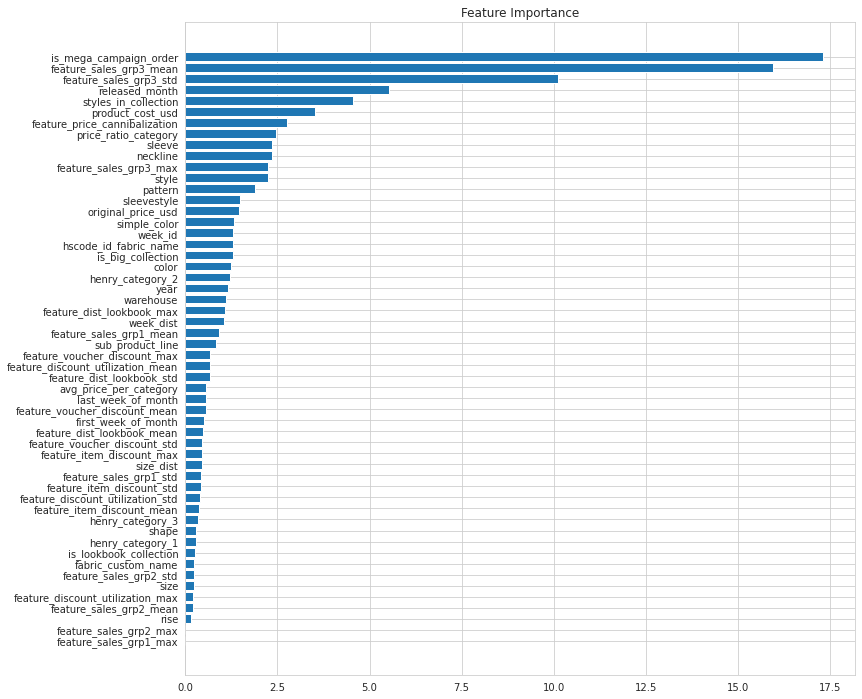

In [81]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(12, 12))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(x_val.columns)[sorted_idx])
plt.title('Feature Importance')

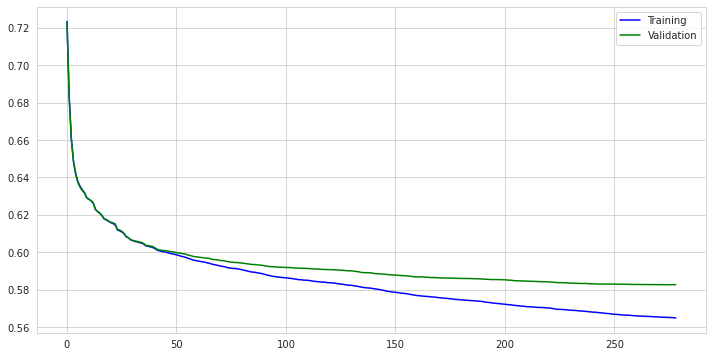

In [82]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12,6))

train_rmse = clf.evals_result_['learn']['RMSE']
val_rmse = clf.evals_result_['validation']['RMSE']
plt.plot(np.arange(0,len(train_rmse)), train_rmse, color = 'blue', label = 'Training')
plt.plot(np.arange(0,len(train_rmse)), val_rmse, color = 'green' ,label = 'Validation')
plt.legend()

In [85]:
data_test = master_join[master_join.release_collection_name.isin(test_set_collections)]
data_test.drop(columns = drop_cols, inplace = True)

In [86]:
data_test = pd.merge(
    data_test,
    feature_dist,
    on = ['warehouse', 'sub_product_line', 'henry_category_2', 'week_id'],
    how = 'left'
)

data_test = pd.merge(
    data_test,
    feature_sales_grp1,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse'],
    how = 'left'
)
data_test = pd.merge(
    data_test,
    feature_sales_grp2,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line'],
    how = 'left'
)
data_test = pd.merge(
    data_test,
    feature_sales_grp3,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line','simple_color'],
    how = 'left'
)

data_test = pd.merge(
    data_test,
    feature_size_dist,
    on = ['henry_category_1', 'warehouse', 'sub_product_line', 'size'],
    how = 'left'
)

data_test = pd.merge(
    data_test,
    feature_week_dist,
    on = ['henry_category_2', 'sub_product_line', 'warehouse', 'week_id',],
    how = 'left'
)

data_test = add_price_features(data_test)

data_test['styles_in_collection'] = data_test.release_collection_name.map(
    dict(data_test.groupby('release_collection_name').id_product.nunique())
)

In [87]:
from src.feature.feature_lib import add_collection_features

In [88]:
data_test.drop(columns = ['is_lookbook_collection', 'is_big_collection'], inplace = True)

In [89]:
data_test['master_style_id'] = data_test.id_product
ms_lookbook = []
data_test = add_collection_features(data_test, ms_lookbook)

In [90]:
data_test.is_lookbook_collection.sum()

0

In [91]:
''' Fill NA '''
X_pred = data_test[FEATURES]
X_pred = X_pred.reindex(columns = x_train.columns)

for col in CATEGORICAL_FEATURES:
    X_pred[col].fillna('others', inplace = True)


for feat in feature_cols:
    X_pred[feat].fillna(np.mean(X_pred[feat]), inplace = True)


# fill na in week_dist
week_dist_fillna = feature_week_dist.groupby("week_id").week_dist.mean()
for week_ in X_pred.week_id.unique():
    X_pred.loc[(X_pred.week_id == week_) & (X_pred.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]
    
# fill na in size dist
#size_dist_fillna = feature_size_dist.groupby("size").size_dist.mean()
#for s in X_pred['size'].unique():
#    X_pred.loc[(X_pred['size'] == s) & (X_pred['size_dist'].isna()), "size_dist"] = size_dist_fillna[s]

X_pred['size_dist'].fillna(np.mean(X_pred['size_dist']), inplace = True)


assert (X_pred.isna().sum().sum() == 0)

In [92]:
data_test['pred'] = clf.predict(X_pred.values)
data_test['pred_round'] = np.round(data_test.pred,2) # keep 2 digits for weekly level
data_test['pred_round'] = np.where(data_test['pred_round'] < 0, 0, data_test['pred_round'])

In [93]:
report_model_performance('weekly data test ', data_test.adjusted_net_units_sold, data_test.pred_round)

Percentage error of weekly data test : 139.0%
Bias of weekly data test : 0.02
Mean absolute error of weekly data test : 0.59
Average actual sales: 0.42
Average prediction: 0.45


In [94]:
data_test_agg = data_test.groupby([
    'id_product', 'color', 'size', 'warehouse', 'sub_product_line','henry_category_1','release_collection_name', 'date_released'
])[['adjusted_net_units_sold', 'pred_round']].sum().reset_index()

data_test_agg['pred_round'] =data_test_agg['pred_round'].round().astype(int)

In [95]:
report_model_performance('catboost model', data_test_agg.adjusted_net_units_sold, data_test_agg.pred_round)

Percentage error of catboost model: 82.0%
Bias of catboost model: 0.19
Mean absolute error of catboost model: 3.12
Average actual sales: 3.82
Average prediction: 4.01


cdc_dist
warehouse model                
ID        actual_data  0.187841
          prediction   0.227358
MY        actual_data  0.194706
          prediction   0.231477
TH        actual_data  0.617453
          prediction   0.541164

<AxesSubplot:xlabel='warehouse', ylabel='cdc_dist'>

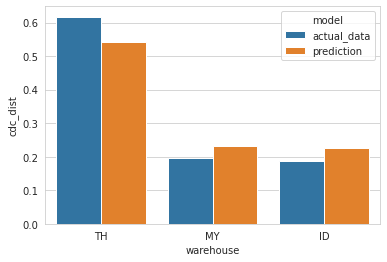

In [96]:
def get_cdc_distribution(input_data: pd.DataFrame, sales_column):
    
    total_sales = input_data[sales_column].sum()

    cdc_dist_data = input_data.groupby(['warehouse'])[sales_column].sum().reset_index()
    cdc_dist_data['cdc_dist'] = cdc_dist_data[sales_column] / total_sales

    return cdc_dist_data[['warehouse','cdc_dist']]


cdc_dist_test = get_cdc_distribution(data_test_agg, 'pred_round')
cdc_dist_test['model'] = 'prediction'

cdc_dist_train = get_cdc_distribution(data_test_agg, 'adjusted_net_units_sold')
cdc_dist_train['model'] = 'actual_data'

cdc_dist = pd.concat([cdc_dist_test, cdc_dist_train])
cdc_dist.sort_values(by = 'cdc_dist', ascending = False, inplace = True)

display(cdc_dist.groupby(['warehouse', 'model'])[['cdc_dist']].mean())
sns.barplot(data = cdc_dist, x = 'warehouse', y = 'cdc_dist', hue = 'model')

In [97]:
''' Check size distribution '''

def get_size_distribution2(input_data, sales_column):
    #input_data = mid_list.copy()
    #sales_column = 'pred_round'

    size_vals = ['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL']
    input_data = input_data[input_data['size'].isin(size_vals)]

    total_size_dist = input_data.groupby(
        ['id_product','color', 'warehouse']
    )[sales_column].sum().reset_index()
    total_size_dist.rename(columns = {sales_column: 'total_volume'}, inplace = True)

    size_dist_data = input_data.groupby(
        ['id_product','color', 'warehouse','size', 'henry_category_1']
    )[sales_column].sum().reset_index()
    size_dist_data.rename(columns = {sales_column: 'size_volume'}, inplace = True)

    size_dist_data = pd.merge(
        size_dist_data,
        total_size_dist,
        on = ['id_product','color', 'warehouse'],
        how = 'left'
    )
    size_dist_data['size_dist'] = size_dist_data['size_volume'] / size_dist_data['total_volume']

    size_dist_data = size_dist_data.groupby(['warehouse','size', 'henry_category_1'])['size_dist'].mean().reset_index()

    size_dist_data['size'] = pd.Categorical(
        size_dist_data['size'], 
        categories=size_vals,
        ordered=True)

    size_dist_data.sort_values(by = 'size', inplace = True)
    size_dist_data['size'] = size_dist_data['size'].astype(str)
    
    return size_dist_data
    
    
size_dist_test = get_size_distribution2(data_test_agg, 'pred_round')
size_dist_test['model'] = 'prediction'


size_dist_train = get_size_distribution2(data_test_agg, 'adjusted_net_units_sold')
size_dist_train['model'] = 'Actual'

size_dist_data = pd.concat([size_dist_test, size_dist_train])


In [98]:
average_size_dist = size_dist_data.groupby(['warehouse','size','model']).size_dist.mean().reset_index()
average_size_dist['size_dist'] = np.round(average_size_dist['size_dist'] * 100,2)

size_vals = ['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL']
average_size_dist['size'] = pd.Categorical(
        average_size_dist['size'], 
        categories=size_vals,
        ordered=True)

average_size_dist.sort_values(by = 'size', inplace = True)

Warehouse: TH
--------


,warehouse,size,model,size_dist
41,TH,XXS,prediction,14.27
40,TH,XXS,Actual,12.16
36,TH,XS,Actual,15.58
37,TH,XS,prediction,18.01
32,TH,S,Actual,22.50
33,TH,S,prediction,22.08
31,TH,M,prediction,20.64
30,TH,M,Actual,20.63
28,TH,L,Actual,16.92
29,TH,L,prediction,15.70


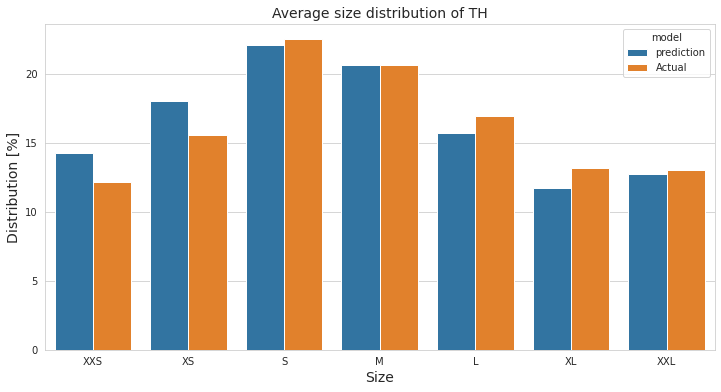

Warehouse: ID
--------


,warehouse,size,model,size_dist
13,ID,XXS,prediction,30.06
12,ID,XXS,Actual,15.23
8,ID,XS,Actual,20.82
9,ID,XS,prediction,18.20
4,ID,S,Actual,26.42
5,ID,S,prediction,24.31
2,ID,M,Actual,21.79
3,ID,M,prediction,23.78
0,ID,L,Actual,17.47
1,ID,L,prediction,16.89


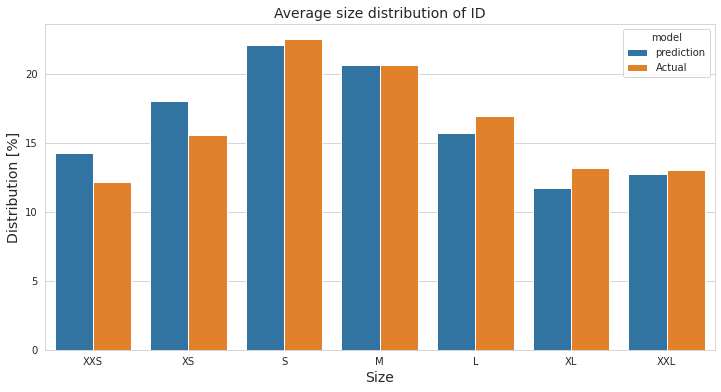

Warehouse: MY
--------


,warehouse,size,model,size_dist
27,MY,XXS,prediction,24.72
26,MY,XXS,Actual,17.48
23,MY,XS,prediction,19.50
22,MY,XS,Actual,21.33
19,MY,S,prediction,26.67
18,MY,S,Actual,26.19
16,MY,M,Actual,19.87
17,MY,M,prediction,22.92
15,MY,L,prediction,14.93
14,MY,L,Actual,16.69


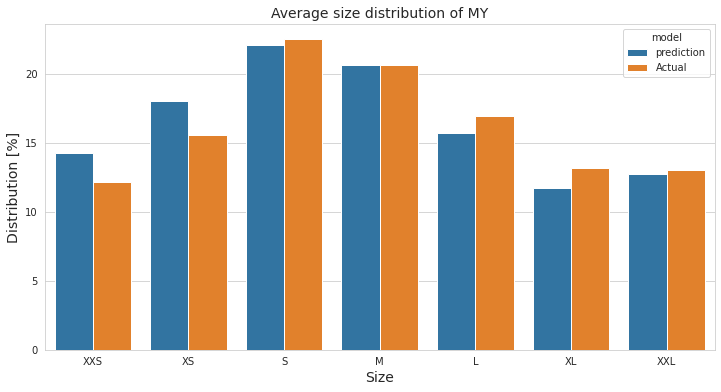

In [99]:
for wh in average_size_dist.warehouse.unique():
    print(f'Warehouse: {wh}')
    print('--------')
    tmp = average_size_dist[average_size_dist.warehouse == wh]
    display(tmp)
    
    fig, ax = plt.subplots(figsize = (12,6))
    sns.set_style('whitegrid')
    tmp = average_size_dist[average_size_dist.warehouse == 'TH']
    sns.barplot(data = tmp, x = tmp['size'], y = tmp.size_dist, hue = 'model')

    plt.title(f'Average size distribution of {wh}', fontsize = 14)
    plt.xlabel('Size', fontsize = 14)
    plt.ylabel('Distribution [%]', fontsize = 14)
    plt.show()
    

In [101]:
''' Create time series plot '''
mj_agg = master_join.groupby(
    ['id_product', 'color', 'size', 'warehouse', 'date_released', 'release_collection_name']
).adjusted_net_units_sold.sum().reset_index()


mj_agg = pd.merge(
    mj_agg,
    data_test_agg[['id_product', 'color', 'size', 'warehouse', 'date_released', 'release_collection_name', 'pred_round']],
    on = ['id_product', 'color', 'size', 'warehouse', 'date_released', 'release_collection_name'],
    how = 'left'
)

Text(0.5, 1.0, 'Test Set Evaluation; accuracy 55.33%')

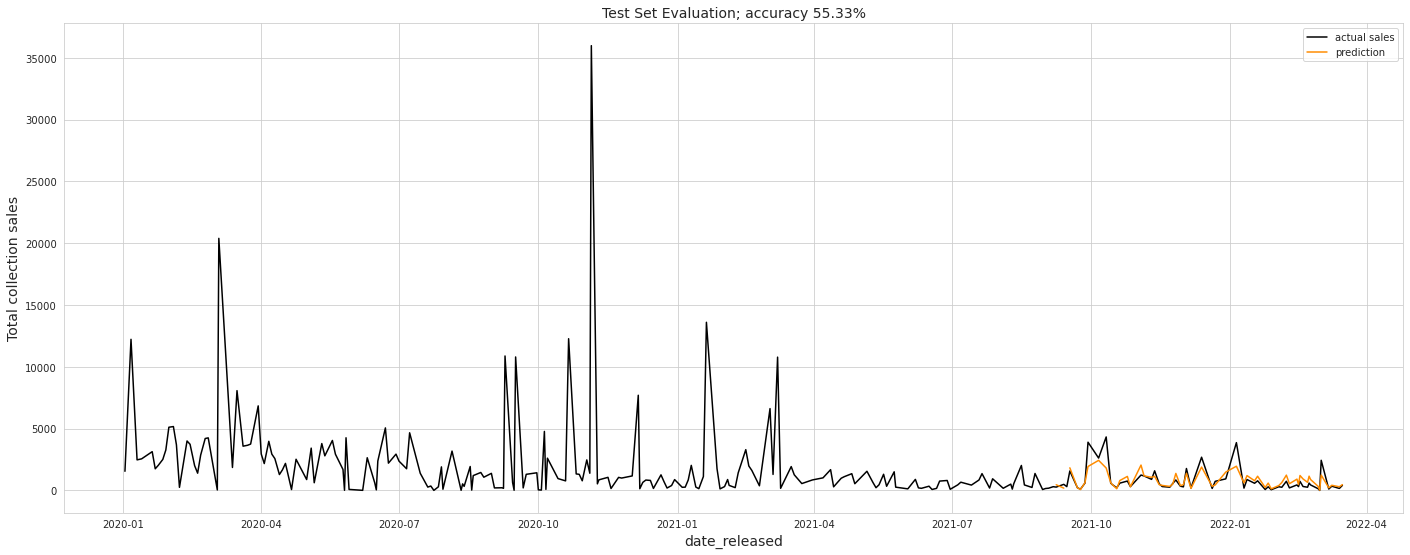

In [102]:
time_series = mj_agg.groupby(['release_collection_name', 'date_released'])[['pred_round','adjusted_net_units_sold']].sum().reset_index()
time_series = time_series.groupby('date_released')[['pred_round','adjusted_net_units_sold']].mean().reset_index()


time_series = time_series[time_series.date_released > pd.to_datetime('2019-12-30')]
time_series.pred_round.replace(0, np.nan, inplace = True)

tmp = time_series.dropna()
acc_ = np.round(accuracy(tmp.adjusted_net_units_sold, tmp.pred_round),2)

fig, ax = plt.subplots(figsize = (24,9))

#sns.set_style('whitegrid')

plt.plot(time_series.date_released, time_series.adjusted_net_units_sold, color = 'black', label = 'actual sales' )
plt.plot(time_series.date_released, time_series.pred_round, color = 'darkorange', label = 'prediction' )
#plt.xlim([0,10000])

plt.legend()

plt.xlabel('date_released', fontsize = 14)
plt.ylabel('Total collection sales', fontsize = 14)
plt.title(f'Test Set Evaluation; accuracy {acc_}%', fontsize = 14)

In [ ]:
ts = mj_agg.groupby(['release_collection_name', 'date_released'])[['pred_round','adjusted_net_units_sold']].sum().reset_index()

In [ ]:
# check feature_dist_lookbook_mean, feature_dist_lookbook_std

In [ ]:
import catboost
from catboost import *
import shap
shap.initjs()

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_pred)

In [ ]:
shap.summary_plot(shap_values, X_pred)

In [ ]:

save_model_to_s3(
    model,
    f'{S3_FOLDER_PATH}/{MODEL_NAME}',
    S3_BUCKET
)

download_file_from_s3(
    f'{LOCAL_MODEL_SAVE_PATH}/{MODEL_NAME}.zip',
    f'{S3_FOLDER_PATH}/{MODEL_NAME}',
    S3_BUCKET
)


In [46]:
FEATURES

Index(['original_price_usd', 'first_week_of_month', 'product_cost_usd', 'is_lookbook_collection', 'year', 'warehouse', 'last_week_of_month', 'is_mega_campaign_order', 'is_big_collection', 'released_month', 'week_id', 'sub_product_line', 'henry_category_1', 'henry_category_2', 'henry_category_3', 'simple_color', 'color', 'fabric_custom_name', 'hscode_id_fabric_name', 'size', 'style', 'sleeve', 'pattern', 'sleevestyle', 'neckline', 'shape', 'rise', 'feature_item_discount_mean', 'feature_item_discount_max', 'feature_item_discount_std', 'feature_voucher_discount_mean', 'feature_voucher_discount_max', 'feature_voucher_discount_std', 'feature_discount_utilization_mean', 'feature_discount_utilization_max', 'feature_discount_utilization_std', 'feature_dist_lookbook_mean', 'feature_dist_lookbook_max', 'feature_dist_lookbook_std', 'feature_sales_grp1_mean', 'feature_sales_grp1_max', 'feature_sales_grp1_std', 'feature_sales_grp2_mean', 'feature_sales_grp2_max', 'feature_sales_grp2_std', 'feature_

# Model Deployment (train final model)

In [11]:
''' Load data  '''


RUN_DATE = '18072022'
S3_FOLDER_PATH = f'data_science/dfm/online_clothing_v2/{RUN_DATE}'
MASTER_JOIN_FILE_PATH = f's3://{S3_BUCKET}/{S3_FOLDER_PATH}/master_join_online.parquet'

FEATURES_ONLINE = [
    'original_price_usd',
    'first_week_of_month',
    'product_cost_usd',
    'is_lookbook_collection',
    'year',
    'warehouse',
    'last_week_of_month',
    'is_mega_campaign_order',
    'is_big_collection',
    'released_month',
    'week_id',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'size',
    'style',
    'sleeve',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'feature_item_discount_mean',
    'feature_item_discount_max',
    'feature_item_discount_std',
    'feature_voucher_discount_mean',
    'feature_voucher_discount_max',
    'feature_voucher_discount_std',
    'feature_discount_utilization_mean',
    'feature_discount_utilization_max',
    'feature_discount_utilization_std',
    'feature_dist_lookbook_mean',
    'feature_dist_lookbook_max',
    'feature_dist_lookbook_std',
    'feature_sales_grp1_mean',
    'feature_sales_grp1_max',
    'feature_sales_grp1_std',
    'feature_sales_grp2_mean',
    'feature_sales_grp2_max',
    'feature_sales_grp2_std',
    'feature_sales_grp3_mean',
    'feature_sales_grp3_max',
    'feature_sales_grp3_std',
    'size_dist',
    'week_dist',
    'avg_price_per_category',
    'price_ratio_category',
    'feature_price_cannibalization',
    'styles_in_collection'
]

CATEGORICAL_FEATURES_ONLINE = [
    'size',
    'warehouse',
    'released_month',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'is_mega_campaign_order',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'first_week_of_month',
    'last_week_of_month',
    'is_lookbook_collection',
    'is_big_collection'
]


In [12]:
READ_COLS = [
    'tie', 'original_price_usd', 'first_week_of_month', 'product_cost_usd', 'is_lookbook_collection', 'year', 'giveaway',
    'warehouse', 'last_week_of_month', 'is_mega_campaign_order', 'discount_utilization', 'item_discount_percent', 'voucher_discount_percent',
    'adjusted_net_units_sold', 'styles_in_drop', 'is_big_collection', 'released_month', 'day_of_week',
    'week_id', 'sub_product_line', 'henry_category_1', 'henry_category_2', 'henry_category_3', 'simple_color',
    'color', 'fabric_custom_name', 'hscode_id_fabric_name', 'size', 'style', 'sleeve', 'pattern', 'sleevestyle',
    'neckline', 'shape', 'rise', 'size_dist', 'dist_lookbook',
] + NO_TRAIN_COLS

master_join = pd.read_parquet( MASTER_JOIN_FILE_PATH, columns = READ_COLS )
master_join = master_join[master_join.week_id <= 9]
master_join.sort_values(by = ['date_released','week_id'], inplace = True)


# Set data_train to master_join so we can copy code from above without renaming
data_train = master_join.copy()

data_train = data_train[data_train.year > 2019]
data_train = data_train[data_train.adjusted_net_units_sold <= data_train.adjusted_net_units_sold.quantile(0.97)]


### Feature engineering

In [13]:
feature_size_dist = get_size_distribution(data_train, 'adjusted_net_units_sold')
feature_week_dist = get_historic_week_dist_feature(data_train)
feature_dist = get_feature_distribution(data_train)
feature_sales_grp1, feature_sales_grp2, feature_sales_grp3 = get_historic_sales_statistics(data_train)

In [14]:
# Drop columns that won't be used in deployment

drop_cols = [
    'tie',
    'giveaway',
    'discount_utilization',
    'item_discount_percent',
    'voucher_discount_percent',
    'dist_lookbook',
    'day_of_week',
    'size_dist',
    'styles_in_drop'
]

data_train.drop(columns = drop_cols, inplace = True)

In [15]:
data_train = pd.merge(
    data_train,
    feature_dist,
    on = ['warehouse', 'sub_product_line', 'henry_category_2', 'week_id'],
    how = 'left'
)

data_train = pd.merge(
    data_train,
    feature_sales_grp1,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse'],
    how = 'left'
)
data_train = pd.merge(
    data_train,
    feature_sales_grp2,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line'],
    how = 'left'
)
data_train = pd.merge(
    data_train,
    feature_sales_grp3,
    on = ['henry_category_2', 'size', 'week_id', 'warehouse', 'sub_product_line','simple_color'],
    how = 'left'
)

data_train = pd.merge(
    data_train,
    feature_size_dist,
    on = ['henry_category_1', 'warehouse', 'size'],
    how = 'left'
)

data_train = pd.merge(
    data_train,
    feature_week_dist,
    on = ['henry_category_2', 'sub_product_line', 'warehouse', 'week_id',],
    how = 'left'
)

data_train = add_price_features(data_train)

data_train['styles_in_collection'] = data_train.release_collection_name.map(
    dict(data_train.groupby('release_collection_name').id_product.nunique())
)

feature_cols = [col for col in data_train.columns if col.startswith('feature_')]

## Model Training

In [16]:
''' Fill NAs '''
for col in CATEGORICAL_FEATURES_ONLINE:
    data_train[col].fillna('others', inplace = True)

for feat in feature_cols:
    data_train[feat].fillna(np.mean(data_train[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = feature_week_dist.groupby("week_id").week_dist.mean()
for week_ in data_train.week_id.unique():
    data_train.loc[(data_train.week_id == week_) & (data_train.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]
    
# fill na in size dist
size_dist_fillna = feature_size_dist.groupby("size").size_dist.mean()
for s in data_train['size'].unique():
    data_train.loc[(data_train['size'] == s) & (data_train['size_dist'].isna()), "size_dist"] = size_dist_fillna[s]
    
assert (data_train[FEATURES_ONLINE].isna().sum().sum() == 0)

In [17]:
cat_idx = [key for key, val in enumerate(FEATURES_ONLINE) if val in set(CATEGORICAL_FEATURES_ONLINE)]

split_ratio = 0.2
x_train, x_val, y_train, y_val = train_test_split(
    data_train[FEATURES_ONLINE],
    data_train["adjusted_net_units_sold"],
    test_size=split_ratio,
    random_state=0
)

In [18]:
clf = CatBoostRegressor(
    depth=8,
    l2_leaf_reg=1.5,
    learning_rate=0.3,
    loss_function='RMSE'
)

clf.fit(
    x_train.values,
    y_train.values, 
    cat_features=cat_idx,
    eval_set=(x_val.values, y_val.values),
    early_stopping_rounds = 5,
    use_best_model = True,
    verbose=True,
    plot = True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7100393	test: 0.7101061	best: 0.7101061 (0)	total: 666ms	remaining: 11m 5s
1:	learn: 0.6729024	test: 0.6732943	best: 0.6732943 (1)	total: 1.32s	remaining: 11m
2:	learn: 0.6523489	test: 0.6531239	best: 0.6531239 (2)	total: 1.85s	remaining: 10m 15s
3:	learn: 0.6410047	test: 0.6420091	best: 0.6420091 (3)	total: 2.38s	remaining: 9m 51s
4:	learn: 0.6345502	test: 0.6356388	best: 0.6356388 (4)	total: 2.98s	remaining: 9m 53s
5:	learn: 0.6303340	test: 0.6314845	best: 0.6314845 (5)	total: 3.56s	remaining: 9m 50s
6:	learn: 0.6277222	test: 0.6290484	best: 0.6290484 (6)	total: 4.06s	remaining: 9m 36s
7:	learn: 0.6261447	test: 0.6274344	best: 0.6274344 (7)	total: 4.57s	remaining: 9m 26s
8:	learn: 0.6222757	test: 0.6231117	best: 0.6231117 (8)	total: 5.11s	remaining: 9m 22s
9:	learn: 0.6212133	test: 0.6221147	best: 0.6221147 (9)	total: 5.58s	remaining: 9m 12s
10:	learn: 0.6201457	test: 0.6211812	best: 0.6211812 (10)	total: 6.14s	remaining: 9m 12s
11:	learn: 0.6175936	test: 0.6182571	best: 

### Save model to S3

In [19]:
ONLINE_MODEL_RUN_DATE = '18072022'
MODEL_NAME_ONLINE = f'catboost_model'
LOCAL_ONLINE_MODEL_SAVE_PATH = f'/home/ec2-user/SageMaker/ml-demand-forecasting/temp/model_saves/online/{ONLINE_MODEL_RUN_DATE}/model_online_{ONLINE_MODEL_RUN_DATE}'
S3_ONLINE_MODEL_SAVE_PATH = f'data_science/dfm/online_clothing_v2/18072022/model_online_{ONLINE_MODEL_RUN_DATE}'


In [20]:
report_model_performance('Validation data', y_val, clf.predict(x_val.values))

Percentage error of Validation data: 95.0%
Bias of Validation data: -0.0
Mean absolute error of Validation data: 0.36
Average actual sales: 0.38
Average prediction: 0.37


/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


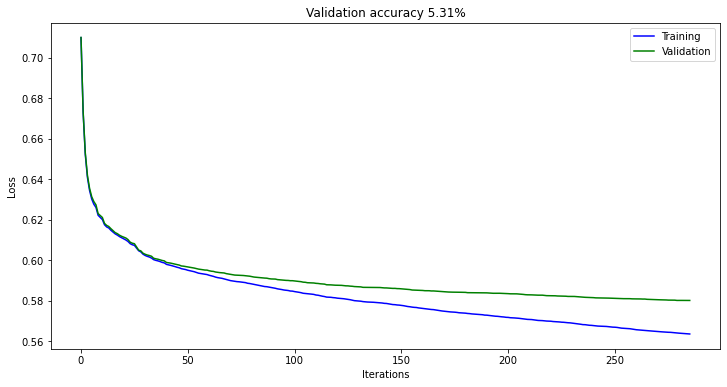

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12,6))

acc_ = np.round(accuracy(y_val, clf.predict(x_val.values)),2)

train_rmse = clf.evals_result_['learn']['RMSE']
val_rmse = clf.evals_result_['validation']['RMSE']
plt.plot(np.arange(0,len(train_rmse)), train_rmse, color = 'blue', label = 'Training')
plt.plot(np.arange(0,len(train_rmse)), val_rmse, color = 'green' ,label = 'Validation')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Validation accuracy {acc_}%')

plt.savefig(f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_train_loss.png')

upload_file_to_s3(
    f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_train_loss.png',
    f'{S3_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_train_loss.png',
    S3_BUCKET
)

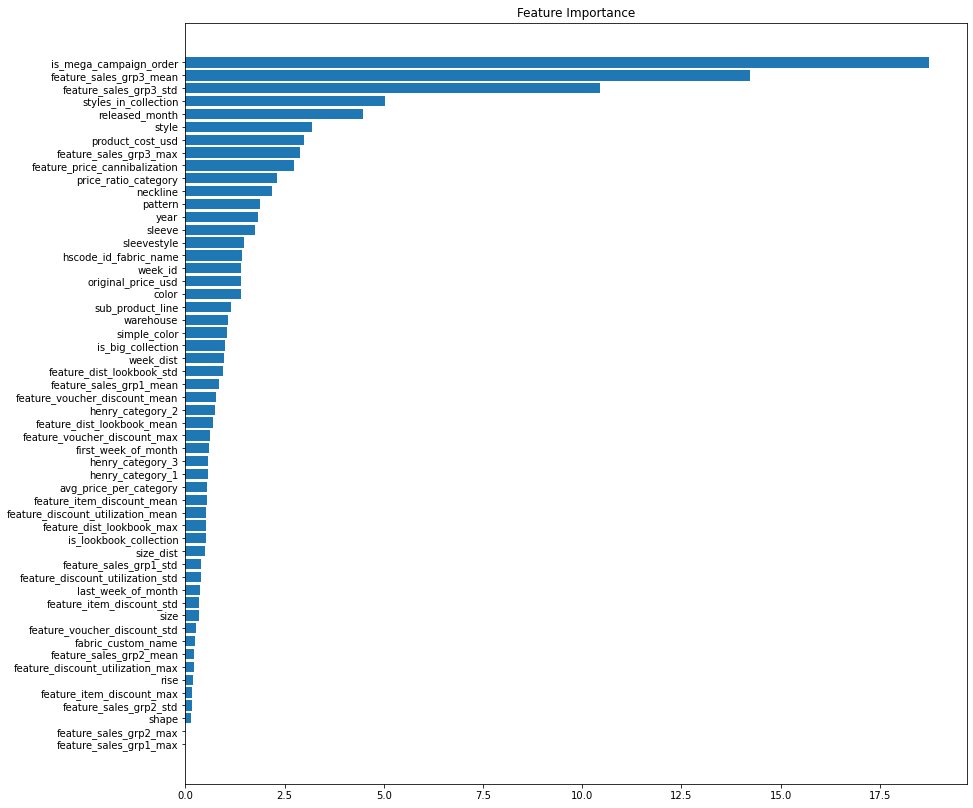

In [24]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(14, 14))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(x_val.columns)[sorted_idx])
plt.title('Feature Importance')
plt.savefig(f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_feature_importance_cat.png')
plt.show()

upload_file_to_s3(
    f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_feature_importance_cat.png',
    f'{S3_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_feature_importance.png',
    S3_BUCKET
)

In [28]:
clf.save_model(f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}')

upload_file_to_s3(
    f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}',
    f'{S3_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}',
    S3_BUCKET
)


In [30]:
# Test load / download 

''' 
download_file_from_s3(
    f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_new',
    f'{S3_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}',
    S3_BUCKET
)

from_file = CatBoostRegressor()
model = from_file.load_model(f'{LOCAL_ONLINE_MODEL_SAVE_PATH}/{MODEL_NAME_ONLINE}_new')

report_model_performance('final catboost model', y_val, model.predict(x_val.values))
'''

'data_science/dfm/online_clothing_v2/18072022/model_online_18072022/catboost_model'

### Set variables for config.model_config.py

In [ ]:
ONLINE_MODEL_RUN_DATE = '18072022'
ONLINE_MODEL_NAME = 'catboost_model'
LOCAL_ONLINE_MODEL_SAVE_PATH = f'/home/ec2-user/SageMaker/ml-demand-forecasting/temp/model_saves/online/{ONLINE_MODEL_RUN_DATE}/model_online_{ONLINE_MODEL_RUN_DATE}/{ONLINE_MODEL_NAME}'
S3_ONLINE_MODEL_SAVE_PATH = f'data_science/dfm/online_clothing_v2/18072022/model_online_{ONLINE_MODEL_RUN_DATE}/{MODEL_NAME_ONLINE}'
S3_ONLINE_DATA_FILE_PATH = f's3://hal-bi-bucket/data_science/dfm/online_clothing_v2/{ONLINE_MODEL_RUN_DATE}/master_join_online.parquet'

FEATURES_ONLINE = [
    'original_price_usd',
    'first_week_of_month',
    'product_cost_usd',
    'is_lookbook_collection',
    'year',
    'warehouse',
    'last_week_of_month',
    'is_mega_campaign_order',
    'is_big_collection',
    'released_month',
    'week_id',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'size',
    'style',
    'sleeve',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'feature_item_discount_mean',
    'feature_item_discount_max',
    'feature_item_discount_std',
    'feature_voucher_discount_mean',
    'feature_voucher_discount_max',
    'feature_voucher_discount_std',
    'feature_discount_utilization_mean',
    'feature_discount_utilization_max',
    'feature_discount_utilization_std',
    'feature_dist_lookbook_mean',
    'feature_dist_lookbook_max',
    'feature_dist_lookbook_std',
    'feature_sales_grp1_mean',
    'feature_sales_grp1_max',
    'feature_sales_grp1_std',
    'feature_sales_grp2_mean',
    'feature_sales_grp2_max',
    'feature_sales_grp2_std',
    'feature_sales_grp3_mean',
    'feature_sales_grp3_max',
    'feature_sales_grp3_std',
    'size_dist',
    'week_dist',
    'avg_price_per_category',
    'price_ratio_category',
    'feature_price_cannibalization',
    'styles_in_collection'
]

CATEGORICAL_FEATURES_ONLINE = [
    'size',
    'warehouse',
    'released_month',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'is_mega_campaign_order',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'first_week_of_month',
    'last_week_of_month',
    'is_lookbook_collection',
    'is_big_collection'
]


### Backup code


In [ ]:
''' Add size range
# To get unique size ranges first we need to order the size values and tranform them to strings
size_vals = [
    'XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL',
    'XXSXS', 'XSS', 'SM', 'ML','LXL', 'XLXXL', 
    '25', '26','27', '28', '30', '32', '34', 
    'O'
]
#assert len(size_vals) == data_test['size'].nunique()

data_test['size'] = pd.Categorical(
    data_test['size'], 
    categories=size_vals,
    ordered=True)

# sort by size to get order
data_test.sort_values(by = 'size', ascending = True, inplace = True)

# Transform back to str so we can apply .unique()
data_test[['size']] = data_test[['size']].astype(str)

size_ranges = data_test.groupby('id_product')['size'].unique().reset_index()

size_ranges['size'] = size_ranges['size'].apply(lambda x: str(x))
data_test['size_range'] = data_test['id_product'].map(dict(size_ranges.values))
print(data_test['size_range'].unique())

# Change to old sizing  
# Get a list of all size ranges that contain XXS
XXS_size_ranges = list()
for el in data_test.size_range.unique():
    sr = el.find('XXS')
    if sr != -1:
        XXS_size_ranges.append(el)
print(f'XXS size ranges: {XXS_size_ranges}')

# Adjust new to old sizes 
#launched_new_sizes = (data_test.first_available_year >= 2022)

has_new_sizes = (
    data_test['size_range'].isin(XXS_size_ranges)
)

new_to_old_size_dict = {
    'XXS' : 'XS',
    'XS' : 'S',
    'S': 'M',
    'M': 'L',
    'L': 'XL',
    'XL': 'XXL',
    'XXSXS': 'XSS',
    'SM': 'ML',
    'LXL': 'XLXXL'
}

#data_test.loc[launched_new_sizes, 'size'] = data_test['size'].map(new_to_old_size_dict)

data_test.loc[data_test['size_range'].isin(XXS_size_ranges), 'old_size'] = data_test['size'].map(new_to_old_size_dict)
data_test.loc[data_test.old_size.isna(), 'old_size'] = data_test['size']

data_test.drop(columns = 'size', axis = 1, inplace = True)
data_test.rename(columns = {'old_size':'size'}, inplace = True)

 '''

In [ ]:
''' 
old_to_new_size_dict = {v: k for k, v in new_to_old_size_dict.items()}

has_new_sizes = (
    data_test['size_range'].isin(XXS_size_ranges)
)

data_test.loc[data_test['size_range'].isin(XXS_size_ranges), 'new_size'] = data_test['size'].map(old_to_new_size_dict)
data_test.loc[data_test['new_size'].isna(), 'new_size'] = data_test['size']

data_test.drop(columns = 'size', axis = 1, inplace = True)
data_test.rename(columns = {'new_size':'size'}, inplace = True)
data_test['size'].unique()

'''

In [ ]:

''' Adjust size distribution  '''
#1 Get size dist from MJ
#2 Merge size dist to prediction table
#3 Get total volume of predictions by id_product
#4 make new prediction based on size dist

def get_size_distribution(input_data, sales_column):
    #input_data = mid_list.copy()
    #sales_column = 'pred_round'

    #size_vals = ['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL']
    #input_data = input_data[input_data['size'].isin(size_vals)]

    total_size_dist = input_data.groupby(
        ['id_product','color', 'warehouse']
    )[sales_column].sum().reset_index()
    total_size_dist.rename(columns = {sales_column: 'total_volume'}, inplace = True)

    size_dist_data = input_data.groupby(
        ['henry_category_1', 'id_product','color', 'warehouse','size']
    )[sales_column].sum().reset_index()
    size_dist_data.rename(columns = {sales_column: 'size_volume'}, inplace = True)

    size_dist_data = pd.merge(
        size_dist_data,
        total_size_dist,
        on = ['id_product','color', 'warehouse'],
        how = 'left'
    )
    size_dist_data['size_dist'] = size_dist_data['size_volume'] / size_dist_data['total_volume']

    size_dist_data = size_dist_data.groupby(['warehouse','size','henry_category_1'])['size_dist'].mean().reset_index()
    
    return size_dist_data

# 1
size_dist_mj = get_size_distribution(master_join[master_join.year == 2022],'adjusted_net_units_sold')
# 2
data_test_agg = pd.merge(
    data_test_agg,
    size_dist_mj,
    on = ['henry_category_1', 'warehouse', 'size'],
    how = 'left'
)

# 3
total_product_sales = data_test_agg.groupby(['id_product', 'color', 'warehouse', 'henry_category_1']).pred_round.sum().reset_index()
total_product_sales.rename(columns = {'pred_round': 'total_sales'}, inplace = True)

data_test_agg = pd.merge(
    data_test_agg,
    total_product_sales, 
    on = ['id_product', 'color', 'henry_category_1', 'warehouse'],
    how = 'left'
)

#4 

data_test_agg['pred_round_new'] = data_test_agg.total_sales * data_test_agg.size_dist


data_test_agg.loc[data_test_agg.pred_round_new.isna(), 'pred_round_new'] = data_test_agg.pred_round
data_test_agg['pred_round_new'] = data_test_agg['pred_round_new'].round().astype(int)